<a href="https://colab.research.google.com/github/RiderTheSpeedLover/Jio_Institute/blob/cox's_Proportional_Hazard_Model/CoxHazardSurvival.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from google.colab import files

# Step 1: Upload the dataset
def upload_file():
    print("Please upload your dataset file (CSV or Excel):")
    uploaded = files.upload()  # File upload for Google Colab
    for file_name in uploaded.keys():
        return file_name

# Load the dataset
file_path = upload_file()

if file_path.endswith('.csv'):
    df = pd.read_csv(file_path)
elif file_path.endswith('.xlsx'):
    df = pd.read_excel(file_path)
else:
    raise ValueError("Unsupported file type. Please upload a CSV or Excel file.")

# Step 2: Handle missing values
# Drop rows with missing target ('rating') or non-numeric independent variables
df = df.dropna(subset=['rating', 'director'])

# Step 3: Filter directors with more than one entry
director_counts = df['director'].value_counts()
frequent_directors = director_counts[director_counts > 1].index

# Step 4: Create a categorical variable for directors
df['director_category'] = df['director'].apply(lambda x: x if x in frequent_directors else "Other")

# Step 5: One-hot encode the 'director_category' column
df_encoded = pd.get_dummies(df, columns=['director_category'], drop_first=True)

# Step 6: Prepare the regression variables
# Drop non-numeric columns and ensure no NaN or infinite values
X = df_encoded.select_dtypes(include=[np.number]).drop(columns=["rating"], errors='ignore')
X = X.replace([np.inf, -np.inf], np.nan)  # Replace infinite values with NaN
X = X.dropna()  # Drop rows with any NaN values

y = df_encoded.loc[X.index, "rating"]  # Align the target variable with filtered rows

# Add a constant to the regression model
X = sm.add_constant(X)

# Step 7: Fit a regression model
model = sm.OLS(y, X).fit()

# Step 8: Display the regression summary
print("\nRegression analysis results:")
print(model.summary())


Please upload your dataset file (CSV or Excel):


Saving imdb_processed.csv to imdb_processed (4).csv

Regression analysis results:
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     77.05
Date:                Thu, 09 Jan 2025   Prob (F-statistic):           1.08e-63
Time:                        18:22:13   Log-Likelihood:                -9167.7
No. Observations:                5554   AIC:                         1.835e+04
Df Residuals:                    5549   BIC:                         1.838e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

In [ ]:
pip install pandas numpy lifelines matplotlib seaborn


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 6.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4031 sha256=2f6a05df0bcf62e96bbd4651686765d524f348a98299cea59180ab23aba31fc0
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Sample Data (Replace with actual file path for large dataset)
data = pd.read_excel("bank-full.xlsx")  # Load dataset

# Drop irrelevant columns (if necessary)
data = data.drop(columns=["contact", "day", "month", "pdays", "previous"])  # Example

# Encode categorical variables
categorical_cols = ["job", "marital", "education", "default", "housing", "loan", "poutcome"]
for col in categorical_cols:
    data[col] = LabelEncoder().fit_transform(data[col])

# Encode target variable
data["y"] = LabelEncoder().fit_transform(data["y"])  # Converts 'no' to 0, 'yes' to 1

# Define features and target
X = data.drop(columns=["y"])
y = data["y"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Identify important variables
feature_importance = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_[0]})
feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)
print("Feature Importance:\n", feature_importance)

Accuracy: 0.8852
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94      7952
           1       0.57      0.19      0.29      1091

    accuracy                           0.89      9043
   macro avg       0.74      0.59      0.61      9043
weighted avg       0.86      0.89      0.86      9043

Feature Importance:
       Feature  Coefficient
8    duration     0.993818
3   education     0.147318
2     marital     0.132180
0         age     0.059605
5     balance     0.052813
1         job     0.040007
4     default    -0.053855
7        loan    -0.235217
10   poutcome    -0.310733
9    campaign    -0.409891
6     housing    -0.550182


customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
dtype: int64


<lifelines.CoxPHFitter: fitted with 5517 total observations, 3761 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
      baseline estimation = breslow
   number of observations = 5517
number of events observed = 1756
   partial log-likelihood = -11309.96
         time fit was run = 2025-02-04 07:41:26 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
gender           -0.05      0.95      0.05           -0.15            0.04                0.86                1.04
SeniorCitizen     0.02      1.02      0.06           -0.09            0.13                0.91                1.14
Partner          -0.14      0.87      0.06           -0.25           -0.03                0.78                0.97
Dependents       -0.04      0.96      0.07           -0.18            0.10                0.83                1.11
PhoneService      1.21      3.35      0.37            0.47            1.94                1.61                6.98
MultipleLines     0.13      1.14      0.13           -0.12            0.38                0.89                1.47
InternetService   1.13      3.10      0.58           -0.01            2.28                0.99                9.74
OnlineSecurity   -0.30      0.74      0.13           -0.56           -0.03                0.57                0.97
OnlineBackup     -0.10      0.91      0.13           -0.35            0.16                0.71                1.17
DeviceProtection  0.04      1.04      0.13           -0.21            0.29                0.81                1.33
TechSupport      -0.13      0.88      0.13           -0.39            0.13                0.68                1.14
StreamingTV       0.28      1.32      0.24           -0.19            0.75                0.83                2.11
StreamingMovies   0.27      1.31      0.24           -0.19            0.74                0.82                2.09
Contract         -1.00      0.37      0.08           -1.16           -0.85                0.31                0.43
PaperlessBilling  0.18      1.20      0.06            0.06            0.30                1.06                1.34
PaymentMethod    -0.15      0.86      0.02           -0.20           -0.11                0.82                0.90
MonthlyCharges    0.02      1.02      0.02           -0.02            0.07                0.98                1.07
TotalCharges     -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00

                  cmp to      z      p  -log2(p)
covariate                                       
gender              0.00  -1.10   0.27      1.88
SeniorCitizen       0.00   0.36   0.72      0.48
Partner             0.00  -2.52   0.01      6.40
Dependents          0.00  -0.57   0.57      0.81
PhoneService        0.00   3.23 <0.005      9.65
MultipleLines       0.00   1.05   0.30      1.76
InternetService     0.00   1.94   0.05      4.26
OnlineSecurity      0.00  -2.22   0.03      5.24
OnlineBackup        0.00  -0.75   0.46      1.13
DeviceProtection    0.00   0.28   0.78      0.36
TechSupport         0.00  -0.97   0.33      1.59
StreamingTV         0.00   1.18   0.24      2.06
StreamingMovies     0.00   1.14   0.25      1.98
Contract            0.00 -12.85 <0.005    123.19
PaperlessBilling    0.00   3.01 <0.005      8.60
PaymentMethod       0.00  -6.53 <0.005     33.87
MonthlyCharges      0.00   0.95   0.34      1.55
TotalCharges        0.00 -41.13 <0.005       inf
---
Concordance = 0.94
Partial AIC = 22655.92
log-likelihood ratio test = 5913.96 on 18 df
-log2(p) of ll-ratio test = inf


Ranked Factors Affecting Churn (by Hazard Ratios - exp(coef)):
                      coef  exp(coef)  se(coef)          z             p
covariate                                                               
PhoneService      1.209171   3.350704  0.374590   3.227986  1.246649e-03
InternetService   1.132336   3.102897  0.583588   1.940301  5.234316e-02
StreamingTV       0.279570   1.322561  0.237586   1.176711  2.393109e-01
StreamingMovies   0.271153   1.311476  0.237395   1.142201  2.533704e-01
PaperlessBilling  0.179101   1.196141  0.059405   3.014921  2.570459e-03
MultipleLines     0.133067   1.142326  0.127318   1.045154  2.959519e-01
DeviceProtection  0.036303   1.036970  0.128106   0.283384  7.768826e-01
MonthlyCharges    0.022016   1.022260  0.023177   0.949908  3.421592e-01
SeniorCitizen     0.020730   1.020947  0.057206   0.362381  7.170677e-01
TotalCharges     -0.002073   0.997930  0.000050 -41.129228  0.000000e+00
Dependents       -0.040967   0.959861  0.072453  -0.565426  

<Axes: xlabel='log(HR) (95% CI)'>

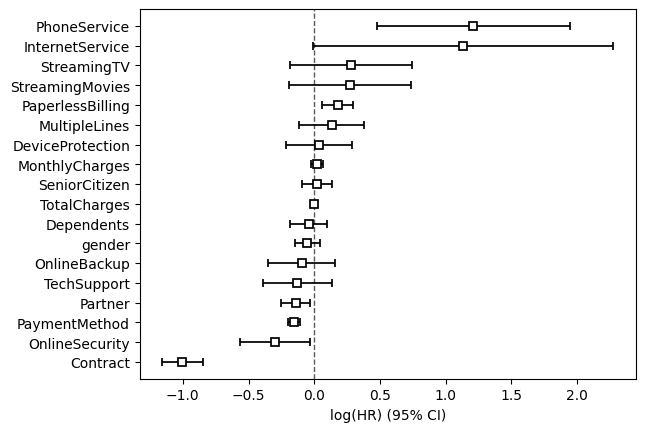

In [ ]:
import pandas as pd
from lifelines import CoxPHFitter

# Load the dataset
data = pd.read_excel('WA_Fn-UseC_-Telco-Customer-Churn.xlsx')

# Preprocess the dataset
# Convert categorical variables to numeric (use dummy variables for categorical columns)
data['gender'] = data['gender'].map({'Female': 0, 'Male': 1})  # Encode gender as 0/1
data['Partner'] = data['Partner'].map({'No': 0, 'Yes': 1})  # Encode Partner as 0/1
data['Dependents'] = data['Dependents'].map({'No': 0, 'Yes': 1})  # Encode Dependents as 0/1
data['PhoneService'] = data['PhoneService'].map({'No': 0, 'Yes': 1})  # Encode PhoneService as 0/1
data['MultipleLines'] = data['MultipleLines'].map({'No phone service': 0, 'No': 1, 'Yes': 2})  # Encode MultipleLines
data['InternetService'] = data['InternetService'].map({'DSL': 0, 'Fiber optic': 1, 'No': 2})  # Encode InternetService
data['OnlineSecurity'] = data['OnlineSecurity'].map({'No': 0, 'Yes': 1})  # Encode OnlineSecurity as 0/1
data['OnlineBackup'] = data['OnlineBackup'].map({'No': 0, 'Yes': 1})  # Encode OnlineBackup as 0/1
data['DeviceProtection'] = data['DeviceProtection'].map({'No': 0, 'Yes': 1})  # Encode DeviceProtection
data['TechSupport'] = data['TechSupport'].map({'No': 0, 'Yes': 1})  # Encode TechSupport as 0/1
data['StreamingTV'] = data['StreamingTV'].map({'No': 0, 'Yes': 1})  # Encode StreamingTV as 0/1
data['StreamingMovies'] = data['StreamingMovies'].map({'No': 0, 'Yes': 1})  # Encode StreamingMovies as 0/1
data['Contract'] = data['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})  # Encode Contract type
data['PaperlessBilling'] = data['PaperlessBilling'].map({'No': 0, 'Yes': 1})  # Encode PaperlessBilling as 0/1
data['PaymentMethod'] = data['PaymentMethod'].map({'Electronic check': 0, 'Mailed check': 1, 'Bank transfer (automatic)': 2, 'Credit card (automatic)': 3})  # Encode PaymentMethod

# Fill missing values in 'TotalCharges' (if any)
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')  # Convert non-numeric to NaN
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].mean())  # Fill NaN with mean value

# Check for any remaining NaN values in the dataset
print(data.isnull().sum())  # This will show the columns with NaN values

# Drop any rows with NaN values (in case other columns still have missing values)
data = data.dropna()

# Define the churn column (binary 0/1)
data['churn'] = data['Churn'].map({'No': 0, 'Yes': 1})  # Convert Churn column to binary

# Define the columns to include in the analysis (excluding 'customerID' as it's an identifier)
columns = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
           'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
           'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
           'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

# Create the Cox Proportional Hazards model
cph = CoxPHFitter()

# Fit the Cox model
cph.fit(data[columns + ['churn']], duration_col='tenure', event_col='churn')

# Print the summary of the model
cph.print_summary()

# Get the model summary as a DataFrame
summary_df = cph.summary

# Rank the variables based on the hazard ratios (exp(coef)) in descending order
ranked_summary = summary_df[['coef', 'exp(coef)', 'se(coef)', 'z', 'p']].sort_values(by='exp(coef)', ascending=False)

# Print the ranked summary
print("\nRanked Factors Affecting Churn (by Hazard Ratios - exp(coef)):")
print(ranked_summary)

# You can also plot the coefficients to visually understand the impact of each variable
cph.plot()